# Ex 2.1

Find out the longest period (measured in the number of days) among the following five periods:

In [6]:
from datetime import datetime

# dates as strings
dates = [{"start": "08/01/2018", "end": "09/04/2018"}, 
         {"start": "16/04/2019", "end": "14/07/2019"}, 
         {"start": "14/10/2018", "end": "13/01/2019"}, 
         {"start": "27/01/2021", "end": "01/05/2021"}, 
         {"start": "17/06/2020", "end": "24/09/2020"}]

def func(d):
    start = datetime.strptime(d["start"], "%d/%m/%Y")
    end = datetime.strptime(d["end"], "%d/%m/%Y")
    diff = end - start
    return diff.days

diffs = [func(x) for x in dates]
diffs

[91, 89, 91, 94, 99]

In [14]:
longest = max(diffs)
idx = diffs.index(longest)
print(f"The longest period is {dates[idx]}, its duration is {longest} days.")

The longest period is {'start': '17/06/2020', 'end': '24/09/2020'}, its duration is 99 days.


# Ex 2.2

After receiving an order (which can be placed on any day of the year), a UK company ships their product within 5 working days. The order is guaranteed to be delivered to the customer within 5 calendar days of the shipment. Create a dataframe which shows, for each order date in 2025, the latest date when the order would be delivered. If the order is placed on 17th May, when will the order be delivered at the latest?

In [15]:
import pandas as pd
from datetime import datetime

dates = pd.date_range(start='2025-01-01', end='2025-12-31', freq='D')
df = pd.DataFrame({"order_date": dates})
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  365 non-null    datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 3.0 KB


In [16]:
uk_holidays = ['2025-01-01', '2025-04-18', '2025-04-21', '2025-05-05',
                '2025-05-26', '2025-08-25', '2025-12-25', '2025-12-26']

df['shipment_date'] = df['order_date'] + pd.offsets.CustomBusinessDay(n=5, holidays=uk_holidays)

df['delivery_date'] = df['shipment_date'] + pd.Timedelta(days=5)

C:\Users\pekarv\AppData\Local\Temp\ipykernel_19944\1853385154.py:4: PerformanceWarning: Non-vectorized DateOffset being applied to Series or DatetimeIndex.
  df['shipment_date'] = df['order_date'] + pd.offsets.CustomBusinessDay(n=5, holidays=uk_holidays)


In [18]:
df[df["order_date"] == datetime(2025, 5, 17)]

,order_date,shipment_date,delivery_date
136,2025-05-17,2025-05-23,2025-05-28


# Ex 2.3

The file "eth-btc-usd-2018-2026.csv" contains the prices of Bitcoin and Etherium between 01/01/2018 and 31/12/2025. Ensure the "Date" column is of the correct datatype and set it to be the index of the dataframe. Create a plot of the two series - "BTC-USD" and "ETH-USD", and comment on whether you think there is any relationship between them.

In [19]:
import pandas as pd
import numpy as np

In [20]:
df = pd.read_csv("eth-btc-usd-2018-2026.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2921 entries, 0 to 2920
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             2921 non-null   object 
 1   BTC-USD          2921 non-null   float64
 2   ETH-USD          2921 non-null   float64
 3   ETH-USD-MISSING  2660 non-null   float64
dtypes: float64(3), object(1)
memory usage: 91.4+ KB


In [21]:
df.head()

,Date,BTC-USD,ETH-USD,ETH-USD-MISSING
0,2018-01-01,13657.200195,772.640991,772.640991
1,2018-01-02,14982.099609,884.443970,884.443970
2,2018-01-03,15201.000000,962.719971,962.719971
3,2018-01-04,15599.200195,980.921997,980.921997
4,2018-01-05,17429.500000,997.719971,997.719971


In [22]:
df["Date"] = pd.to_datetime(df["Date"], format="%Y-%m-%d")
df = df.set_index("Date")

<Axes: xlabel='Date'>

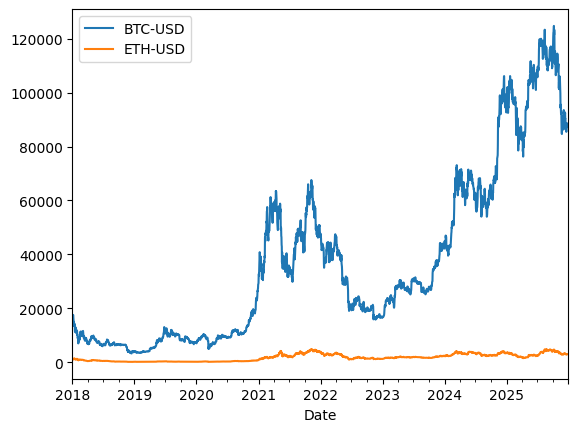

In [24]:
df[["BTC-USD", "ETH-USD"]].plot()

# Ex 2.4

Use the data in "eth-btc-usd-2018-2026.csv" to find answers to the following questions:

1. What was the largest daily increase of the BTC price? What was its largest daily drop?
2. What was the largest monthly increase and drop of BTC?

In [68]:
import pandas as pd
import numpy as np

In [69]:
df = pd.read_csv("eth-btc-usd-2018-2026.csv", parse_dates=["Date"], date_format="%Y-%m-%d")
df = df.set_index("Date")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2921 entries, 2018-01-01 to 2025-12-30
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BTC-USD          2921 non-null   float64
 1   ETH-USD          2921 non-null   float64
 2   ETH-USD-MISSING  2660 non-null   float64
dtypes: float64(3)
memory usage: 91.3 KB


In [70]:
# daily difference

df["BTC-USD-diff"] = df["BTC-USD"].diff()

In [72]:
# What was the largest daily increase? What was its largest daily drop?
df["BTC-USD-diff"].max(), df["BTC-USD-diff"].min()

(8227.296875, -8491.21875)

In [74]:
# What was the largest monthly increase and drop?
tdf = df.resample("ME").sum()
tdf.head()

,BTC-USD,ETH-USD,ETH-USD-MISSING,BTC-USD-diff
Date,,,,
2018-01-31,405652.300781,34213.026123,30827.807129,-3436.100586
2018-02-28,265216.032227,24447.256897,22549.220886,176.800781
2018-03-31,280257.270020,19398.601074,15960.688110,-3424.370605
2018-04-30,241007.898926,15633.110016,13212.952026,2267.020020
2018-05-31,261980.929688,21042.661072,19196.705017,-1746.379883


In [75]:
tdf["BTC-USD-diff"].max(), tdf["BTC-USD-diff"].min()

(26233.8671875, -20417.3203125)

# Ex.2.5

The first two columns in "eth-btc-usd-2018-2026.csv" contain prices of Bitcoin (BTC) and Etherium (ETH). The third column, "ETH-USD-MISSING", contains the same observations for ETH, but with some observations missing.

1. Create a dataframe containing the daily price changes of BTC-USD and ETH-USD.
2. Find out if ETH is related to BTC in this dataframe, by measuring the cross-correlation between them.
3. Compare how the cross-correlation changes depending on whether linear, quadratic (polynomial, 2nd order) or cubic (polynomial, 3rd order) interpolation is used to supply missing values in "ETH-USD-MISSING".

In [25]:
import pandas as pd
import numpy as np

In [28]:
df = pd.read_csv("eth-btc-usd-2018-2026.csv", parse_dates=["Date"], date_format="%Y-%m-%d")
df = df.set_index("Date")
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2921 entries, 2018-01-01 to 2025-12-30
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BTC-USD          2921 non-null   float64
 1   ETH-USD          2921 non-null   float64
 2   ETH-USD-MISSING  2660 non-null   float64
dtypes: float64(3)
memory usage: 91.3 KB


In [57]:
# Create a new dataframe that contains daily changes of the values in these three columns. 
# delete the first row, as it contains NaNs
df2 = df.diff().iloc[1:,:]

df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2920 entries, 2018-01-02 to 2025-12-30
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   BTC-USD          2920 non-null   float64
 1   ETH-USD          2920 non-null   float64
 2   ETH-USD-MISSING  2416 non-null   float64
 3   ETH-USD-linear   2920 non-null   float64
dtypes: float64(4)
memory usage: 114.1 KB


<Axes: xlabel='Date'>

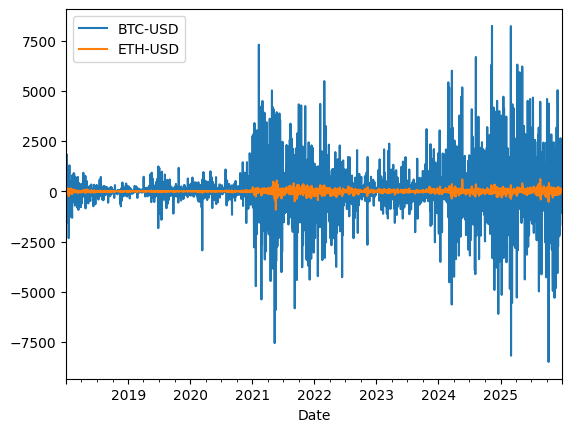

In [58]:
# Create a plot of the daily changes
df2[["BTC-USD", "ETH-USD"]].plot()

In [59]:
# Find out if ETH is related to BTC, by measuring the cross-correlation between them.
np.corrcoef(df2["ETH-USD"], df2["BTC-USD"])

array([[1.        , 0.76854376],
       [0.76854376, 1.        ]])

In [60]:
# Supply missing values in ETH-USD-MISSING using linear interpolation

df2["ETH-USD-linear"] = df2["ETH-USD-MISSING"].interpolate(method="linear", axis=0)

In [61]:
# Find out the cross-correlation between BTC-USD and ETH-USD-linear
np.corrcoef(df2["ETH-USD-linear"], df2["BTC-USD"])

array([[1.        , 0.66095142],
       [0.66095142, 1.        ]])

In [65]:
# Supply missing values in ETH-USD-MISSING using quadratic interpolation

df2["ETH-USD-quad"] = df2["ETH-USD-MISSING"].interpolate(method="polynomial", order=2, axis=0)

In [66]:
# Find out the cross-correlation between BTC-USD and ETH-USD-quad
np.corrcoef(df2["ETH-USD-quad"], df2["BTC-USD"])

array([[1.        , 0.57460451],
       [0.57460451, 1.        ]])

In [67]:
# Supply missing values in ETH-USD-MISSING using cubic interpolation
df2["ETH-USD-cubic"] = df2["ETH-USD-MISSING"].interpolate(method="polynomial", order=3, axis=0)
np.corrcoef(df2["ETH-USD-cubic"], df2["BTC-USD"])

array([[1.      , 0.570627],
       [0.570627, 1.      ]])